# 架構 A2 — 從 A 分支出去的 Blackboard 派工版本

這份是從 `A_full_custom_langgraph.ipynb` 分支出來的變體，只換掉中間的**派工機制**：
`plan_waves`/`dispatch_wave`/`code_agent`/`advance_or_finish` 這一組「事先算好整批怎麼分波、
用 `Send` 集中指派」的邏輯，換成 **blackboard 模式**——`plan_slices` 把所有 change 丟到一塊
共用的黑板（`store`）上，各自獨立的 worker（實務上就是 `labs/` 驗證過的那種 `claude` CLI
subprocess）自己去黑板上找還沒被認領、跟目前進行中的工作沒有 `touches` 重疊的任務，主動認領、
做完、寫回結果，不等一整批(波)全部做完才開始下一批。

其餘節點（`align_requirements`、`test_agent`/`review_agent`、`synthesize_verdict`、
`review_gate`、`human_checkpoint`、`push_or_mr`）跟 A 完全一樣，不重複解釋。

## 這份 sketch 想具體證明的一件事：波次邊界會不必要地拖慢進度

用同一組 4 個 slice 示範（`touches` 故意設計成只有 A/C 衝突，B、D 都各自獨立），`plan_waves`
的貪婪分波演算法會把 `[A, B, D]` 分進同一波（互不衝突），`[C]` 單獨分進下一波（衝突 A）。
問題是：**「同一波」是一個全有全無的同步邊界**——就算 D 比 A 慢很多，`C` 也必須等整個第一波
（包含 D）做完才能開始，即使 `C` 真正衝突的對象只有 `A`，跟 `D` 完全無關。Blackboard 模式下，
`C` 只要 `A` 一做完就能立刻被認領，不用管 `D` 做到哪。

下面直接用程式算出兩種模式各自要跑幾輪，不是用嘴巴講「應該會比較快」。

In [1]:
import fnmatch
import operator
import sys
from typing import Annotated, Literal, TypedDict

sys.path.insert(0, "..")  # 這份 notebook 在 notebooks/arch/ 底下，_graph_viz.py 在上一層
from langchain_core.runnables import RunnableConfig
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.config import get_store
from langgraph.graph import END, START, StateGraph
from langgraph.store.memory import InMemoryStore
from langgraph.types import Command, interrupt

from _graph_viz import show_graph

## State

跟 A 幾乎一樣，拿掉 `waves`/`current_wave`（blackboard 模式沒有「波」這個概念），`slices`
維持原樣——這代表 `plan_slices` 這個節點完全不用改，兩種派工模式吃的是同一份輸入。

In [2]:
class DevWorkflowState(TypedDict):
    requirement: str
    slices: list[dict]        # [{"id": "...", "touches": ["glob", ...]}] —— 跟 A 完全一樣
    code_changes: Annotated[list[str], operator.add]  # 注意：review 沒過重派時不會重跑 plan_slices 清空這欄，所以整個 thread 是累加的，不是「這一輪的」code_changes——這裡故意留白沒處理，示範用看得懂結果就好，正式接線要修
    test_report: str
    review_report: str
    review_rounds: int
    review_feedback: str
    verdict_passed: bool
    verdict_reason: str
    blackboard_total_rounds: int   # 只是這份 sketch 拿來驗證用的欄位，A 沒有這個概念
    blackboard_log: list[str]      # 同上——認領/完成的逐輪紀錄，方便驗證認領順序對不對

## `align_requirements` / `plan_slices`：跟 A 逐字相同

不重複貼冗長註解——這兩個節點的職責、跟 OpenSpec 的對應方式，跟 A 完全一樣。這裡刻意用跟 A
同樣故事線的 4 個 slice（多加一個獨立、但故意跑很慢的 `slice-D`，用來凸顯波次邊界的問題）。

In [3]:
def align_requirements(state: DevWorkflowState, config: RunnableConfig) -> dict:
    store = get_store()
    thread_id = config["configurable"]["thread_id"]
    feedback = store.get(("workflow", thread_id), "last_feedback")

    requirement = state.get("requirement") or "（示意）需求描述"
    if feedback:
        requirement += f"（依上一輪回饋調整：{feedback.value['reason']}）"

    return {"requirement": requirement}


# 每個 slice 額外帶一個 duration（示意「做完需要幾輪」），是這份 sketch 專屬的欄位，
# 用來量化比較兩種派工模式的總輪數——A 的 plan_slices 沒有這個欄位，因為那份 sketch
# 不需要量化比較執行時間。
SLICE_DURATIONS = {"slice-A": 2, "slice-B": 1, "slice-C": 1, "slice-D": 5}


def plan_slices(state: DevWorkflowState) -> dict:
    # 跟 A 一樣：實務上這裡是把 align_requirements 的大 spec 餵給 OpenSpec 的 /proposal
    # 拆成多個 change。slice-A/slice-C 故意宣告同一個 touches（會衝突），slice-B/slice-D
    # 各自獨立、互不衝突——slice-D 刻意給一個很長的 duration，用來示範波次邊界的問題。
    slices = [
        {"id": "slice-A", "touches": ["src/api/**"]},
        {"id": "slice-B", "touches": ["src/ui/**"]},
        {"id": "slice-C", "touches": ["src/api/**"]},
        {"id": "slice-D", "touches": ["src/docs/**"]},
    ]
    return {"slices": slices, "code_changes": [], "review_rounds": 0, "review_feedback": ""}

## 對照組：A 的 `plan_waves` 貪婪分波，套在同樣 4 個 slice 上會怎麼分

直接重用 A 的分波演算法（逐字照抄，不是另外寫一份簡化版），算出這 4 個 slice 實際會被分成
哪幾波，然後用 `max(duration)` 算出「這一波要等最慢的那個做完」的邏輯，得出波次模式總共
要跑幾輪。

In [4]:
def plan_waves_like_A(slices: list[dict]) -> list[list[str]]:
    # 跟 A_full_custom_langgraph.ipynb 的 plan_waves 完全同一份演算法：
    # 逐一嘗試塞進「目前已存在、且不會跟裡面任何 slice 衝突」的第一個波，塞不進才開新波。
    waves: list[list[str]] = []
    for s in slices:
        for wave in waves:
            overlaps = any(
                fnmatch.fnmatch(t, other_t) or fnmatch.fnmatch(other_t, t)
                for other_id in wave
                for other_t in next(x["touches"] for x in slices if x["id"] == other_id)
                for t in s["touches"]
            )
            if not overlaps:
                wave.append(s["id"])
                break
        else:
            waves.append([s["id"]])
    return waves


demo_slices = [
    {"id": "slice-A", "touches": ["src/api/**"]},
    {"id": "slice-B", "touches": ["src/ui/**"]},
    {"id": "slice-C", "touches": ["src/api/**"]},
    {"id": "slice-D", "touches": ["src/docs/**"]},
]
waves = plan_waves_like_A(demo_slices)
print("分波結果：", waves)

wave_based_total_rounds = sum(max(SLICE_DURATIONS[sid] for sid in wave) for wave in waves)
print("波次模式：每一波要等最慢的那個做完，總輪數 =", " + ".join(
    str(max(SLICE_DURATIONS[sid] for sid in wave)) for wave in waves
), "=", wave_based_total_rounds)
print("（slice-C 明明只跟 slice-A 衝突，卻要多等 slice-D 做完才能開始——這就是波次邊界的代價）")

分波結果： [['slice-A', 'slice-B', 'slice-D'], ['slice-C']]
波次模式：每一波要等最慢的那個做完，總輪數 = 5 + 1 = 6
（slice-C 明明只跟 slice-A 衝突，卻要多等 slice-D 做完才能開始——這就是波次邊界的代價）


## Blackboard 派工：`post_to_blackboard` + `blackboard_dispatch`

取代 A 的 `plan_waves`/`dispatch_wave`/`code_agent`/`advance_or_finish` 這四個節點。

- **`post_to_blackboard`**：把所有 slice 當成「未認領」的任務寫進 `store`，不做任何分波
  判斷——判斷交給下面的認領邏輯在真正執行時動態決定，不是這裡事先算好。
- **`blackboard_dispatch`**：這裡誠實地用**單一 process 內的回合制模擬**，代表「N 個獨立的
  `claude` CLI worker 各自跑自己的認領迴圈」這件事——實務上這些 worker 是外部各自獨立的
  process，不是 LangGraph 自己用 `Send` 管理的平行分支（這是跟 A 在執行模型上真正的差異：
  A 的平行是 LangGraph 自己管的，這裡的平行發生在 LangGraph 看不到的地方，LangGraph 只負責
  貼工作、等結果）。

**這輪討論後新增、但要老實講清楚一個限制**：A 那邊已經驗證過「`code_agent` 中途卡住問問題，
不會擋到其他平行的 slice」——這件事在**真實部署**下 A2 也一樣成立（甚至更自然，因為 A2 的
worker 本來就是外部各自獨立的 process，互不相干）。但**這份 sketch 沒辦法真的示範這件事**：
下面 `blackboard_dispatch` 是單一 process 內的同步 Python 迴圈在模擬多個 worker，不是真的
平行分支——如果在這個迴圈裡面真的呼叫 `interrupt()`，會暫停整個 `blackboard_dispatch`
這個節點，連帶把所有還在跑的 worker 都一起卡住，不是只卡住問問題的那一個，這跟真實部署的
行為不一樣。要在 sketch 層級也示範這件事，`blackboard_dispatch` 需要重新設計成真的用 `Send`
把每個 worker 拆成獨立分支（會讓這份 sketch 更接近 A 的結構），這裡先誠實記錄這個限制，
不假裝已經解決。

In [5]:
def touches_overlap(a_touches: list[str], b_touches: list[str]) -> bool:
    return any(
        fnmatch.fnmatch(a, b) or fnmatch.fnmatch(b, a) for a in a_touches for b in b_touches
    )


def post_to_blackboard(state: DevWorkflowState, config: RunnableConfig) -> dict:
    store = get_store()
    thread_id = config["configurable"]["thread_id"]
    slice_by_id = {s["id"]: s for s in state["slices"]}
    tasks = {
        sid: {
            "touches": s["touches"],
            "status": "unclaimed",
            "claimed_by": None,
            "rounds_left": SLICE_DURATIONS[sid],
        }
        for sid, s in slice_by_id.items()
    }
    store.put(("blackboard", thread_id), "tasks", {"tasks": tasks})
    return {}


def claim_task(store, thread_id: str, worker_id: str) -> str | None:
    key = ("blackboard", thread_id)
    tasks = store.get(key, "tasks").value["tasks"]
    in_progress_touches = [t["touches"] for t in tasks.values() if t["status"] == "in_progress"]

    for task_id, task in tasks.items():
        if task["status"] != "unclaimed":
            continue
        if any(touches_overlap(task["touches"], busy) for busy in in_progress_touches):
            continue
        # 認領前重讀一次，確認還沒被別的 worker 搶走——InMemoryStore 沒有真的
        # compare-and-swap，這裡只是模擬那個檢查該長怎樣；正式上線要換成真的支援
        # 原子操作的後端（Postgres row lock / Redis SETNX），不能直接照搬這份 sketch。
        latest = store.get(key, "tasks").value["tasks"]
        if latest[task_id]["status"] != "unclaimed":
            continue
        tasks[task_id]["status"] = "in_progress"
        tasks[task_id]["claimed_by"] = worker_id
        store.put(key, "tasks", {"tasks": tasks})
        return task_id
    return None


N_WORKERS = 3
MAX_ROUNDS = 50  # 防呆上限，避免邏輯寫錯造成無限迴圈


def blackboard_dispatch(state: DevWorkflowState, config: RunnableConfig) -> dict:
    # 實務上每個 worker 遇到「這裡我不能自己決定」的情況，做法跟 A 的 code_agent 一樣：
    # claude CLI 呼叫帶 --json-schema 逼它回答 needs_clarification，true 就跳出來問——
    # 只是在真實部署下，這個「跳出來問」發生在外部獨立的 process 裡，不會透過這個節點的
    # interrupt() 走，所以這份 sketch 沒有示範這一段（見上面 markdown 的說明）。
    store = get_store()
    thread_id = config["configurable"]["thread_id"]
    key = ("blackboard", thread_id)
    worker_ids = [f"worker-{i+1}" for i in range(N_WORKERS)]
    current_task: dict[str, str | None] = {w: None for w in worker_ids}
    log: list[str] = []

    for round_no in range(1, MAX_ROUNDS + 1):
        for worker_id in worker_ids:
            if current_task[worker_id] is None:
                claimed = claim_task(store, thread_id, worker_id)
                if claimed:
                    current_task[worker_id] = claimed
                    log.append(f"round {round_no}: {worker_id} 認領 {claimed}")
                else:
                    log.append(f"round {round_no}: {worker_id} 沒有可認領的工作，閒置")
                    continue

            task_id = current_task[worker_id]
            tasks = store.get(key, "tasks").value["tasks"]
            tasks[task_id]["rounds_left"] -= 1
            if tasks[task_id]["rounds_left"] <= 0:
                tasks[task_id]["status"] = "done"
                log.append(f"round {round_no}: {worker_id} 完成 {task_id}")
                current_task[worker_id] = None
            store.put(key, "tasks", {"tasks": tasks})

        # 完成檢查故意放在這一輪的工作做完「之後」，不是下一輪開始「之前」——
        # 放在迴圈開頭檢查會多算一輪（最後一個任務做完那一輪之後，還要再進迴圈一次
        # 才會發現全部完成，round_no 會多 1），這裡是寫完跑過一次才發現這個 off-by-one
        # 才改成迴圈尾端檢查。
        tasks = store.get(key, "tasks").value["tasks"]
        if all(t["status"] == "done" for t in tasks.values()):
            break
    else:
        raise RuntimeError(f"超過 {MAX_ROUNDS} 輪還沒做完，邏輯可能有問題")

    final_tasks = store.get(key, "tasks").value["tasks"]
    code_changes = [f"{sid} 已完成（blackboard 模式，示意）" for sid in final_tasks]
    return {"code_changes": code_changes, "blackboard_total_rounds": round_no, "blackboard_log": log}

## 直接跑一次，驗證兩件事

1. `slice-C` 確實是等 `slice-A` 顯示完成之後才被認領（不是隨便什麼時候都能認領，衝突判斷
   是真的在生效）。
2. Blackboard 模式的總輪數，真的比波次模式（上面算出來的 `wave_based_total_rounds`）少。

In [6]:
test_builder = StateGraph(DevWorkflowState)
test_builder.add_node("post_to_blackboard", post_to_blackboard)
test_builder.add_node("blackboard_dispatch", blackboard_dispatch)
test_builder.add_edge(START, "post_to_blackboard")
test_builder.add_edge("post_to_blackboard", "blackboard_dispatch")
test_builder.add_edge("blackboard_dispatch", END)
test_graph = test_builder.compile(store=InMemoryStore())

result = test_graph.invoke(
    {"requirement": "", "slices": demo_slices, "code_changes": [], "review_rounds": 0, "review_feedback": ""},
    {"configurable": {"thread_id": "demo-blackboard"}},
)

for line in result["blackboard_log"]:
    print(line)

print()
print("blackboard 模式總輪數：", result["blackboard_total_rounds"])
print("波次模式總輪數：", wave_based_total_rounds)

claim_c_round = next(i for i, line in enumerate(result["blackboard_log"]) if "認領 slice-C" in line)
done_a_round = next(i for i, line in enumerate(result["blackboard_log"]) if "完成 slice-A" in line)
assert claim_c_round > done_a_round, "slice-C 應該要在 slice-A 完成之後才被認領"
assert result["blackboard_total_rounds"] < wave_based_total_rounds, "blackboard 模式應該比波次模式快"
print("\n驗證通過：slice-C 確實等 slice-A 做完才認領；blackboard 總輪數確實比波次模式少。")

round 1: worker-1 認領 slice-A
round 1: worker-2 認領 slice-B
round 1: worker-2 完成 slice-B
round 1: worker-3 認領 slice-D
round 2: worker-1 完成 slice-A
round 2: worker-2 認領 slice-C
round 2: worker-2 完成 slice-C
round 3: worker-1 沒有可認領的工作，閒置
round 3: worker-2 沒有可認領的工作，閒置
round 4: worker-1 沒有可認領的工作，閒置
round 4: worker-2 沒有可認領的工作，閒置
round 5: worker-1 沒有可認領的工作，閒置
round 5: worker-2 沒有可認領的工作，閒置
round 5: worker-3 完成 slice-D

blackboard 模式總輪數： 5
波次模式總輪數： 6

驗證通過：slice-C 確實等 slice-A 做完才認領；blackboard 總輪數確實比波次模式少。


## 組完整圖：其餘節點跟 A 完全一樣

`merge_all`（對應 A 的 `merge_wave`，但是合併「全部做完的 slice」，不是「某一波」）、
`resolve_conflict`、`test_agent`/`review_agent`/`synthesize_verdict`/`review_gate`/
`human_checkpoint`/`push_or_mr`，邏輯跟 A 完全相同，差別只在 `review_gate` 重派時
回到的是 `post_to_blackboard`（重新把所有 slice 丟回黑板），不是 `dispatch_wave`。

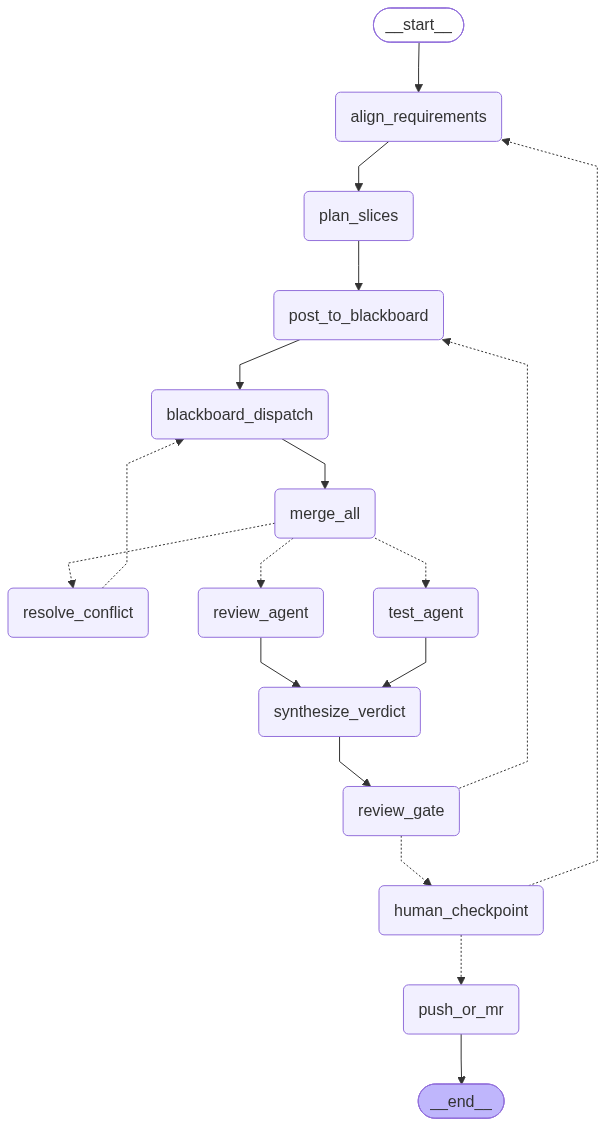

In [7]:
def merge_all(state: DevWorkflowState) -> Command[Literal["resolve_conflict", "test_agent", "review_agent"]]:
    # 跟 A 的 merge_wave 同一套安全檢查順序（借用 references/nimbalyst 的
    # GitWorktreeService.mergeToMain()），差別只是這裡一次合併「全部做完的 slice」，
    # 不是「某一波」——blackboard 模式沒有波的概念，所有 slice 都做完才會走到這裡。
    # 沒衝突時要同時 fan out 給 test_agent 跟 review_agent（兩個獨立驗證視角都要跑），
    # 跟 A 的 advance_or_finish 在沒有下一波時的 Command(goto=["test_agent", "review_agent"])
    # 是同一招——這裡一開始漏寫成只 goto "test_agent"，會導致 review_agent 永遠不會執行、
    # synthesize_verdict 讀 state["review_report"] 時直接 KeyError，寫完後才發現改回來。
    conflict = False  # 這份 sketch 不模擬真的合併衝突，跟 A 一樣
    return Command(goto="resolve_conflict" if conflict else ["test_agent", "review_agent"])


def resolve_conflict(state: DevWorkflowState, config: RunnableConfig) -> Command[Literal["blackboard_dispatch"]]:
    # 示意：真實邏輯是把有衝突的 slice 狀態重設回 unclaimed，重新丟回黑板讓 worker
    # 認領，不是像 A 那樣「回頭重派整波」——blackboard 模式下可以只重設真的衝突的
    # 那幾個 slice，不用整批重來，這是它比波次模式更精細的地方。
    return Command(goto="blackboard_dispatch")


def test_agent(state: DevWorkflowState) -> dict:
    return {"test_report": "PASS（示意）"}


def review_agent(state: DevWorkflowState) -> dict:
    return {"review_report": "PASS（示意）"}


def synthesize_verdict(state: DevWorkflowState) -> dict:
    # 跟 A 完全一樣的邏輯，不重複解釋理由。
    test_ok = state["test_report"].startswith("PASS")
    review_ok = state["review_report"].startswith("PASS")
    passed = test_ok and review_ok
    reason = "test 與 review 都過" if passed else "test 或 review 沒過"
    return {"verdict_passed": passed, "verdict_reason": reason}


MAX_REVIEW_ROUNDS = 2


def review_gate(state: DevWorkflowState) -> Command[Literal["post_to_blackboard", "human_checkpoint"]]:
    if state["verdict_passed"]:
        return Command(goto="human_checkpoint")

    review_rounds = state.get("review_rounds", 0)
    if review_rounds >= MAX_REVIEW_ROUNDS:
        return Command(
            update={"review_feedback": "連續兩輪 review 沒過，交還人工判斷是不是方向錯了"},
            goto="human_checkpoint",
        )
    return Command(
        update={"review_rounds": review_rounds + 1, "review_feedback": state["verdict_reason"]},
        goto="post_to_blackboard",
    )


def human_checkpoint(
    state: DevWorkflowState, config: RunnableConfig
) -> Command[Literal["align_requirements", "push_or_mr"]]:
    store = get_store()
    thread_id = config["configurable"]["thread_id"]
    decision = interrupt(
        {
            "code_changes": state["code_changes"],
            "test_report": state["test_report"],
            "review_report": state["review_report"],
            "ask": "方向對嗎？resume 一個 dict：{'approve': True} 或 {'approve': False, 'reason': ...}",
        }
    )
    if decision.get("approve"):
        return Command(goto="push_or_mr")
    store.put(("workflow", thread_id), "last_feedback", {"reason": decision.get("reason", "")})
    return Command(goto="align_requirements")


def push_or_mr(state: DevWorkflowState) -> dict:
    return {}


builder = StateGraph(DevWorkflowState)
builder.add_node("align_requirements", align_requirements)
builder.add_node("plan_slices", plan_slices)
builder.add_node("post_to_blackboard", post_to_blackboard)
builder.add_node("blackboard_dispatch", blackboard_dispatch)
builder.add_node("merge_all", merge_all)
builder.add_node("resolve_conflict", resolve_conflict)
builder.add_node("test_agent", test_agent)
builder.add_node("review_agent", review_agent)
builder.add_node("synthesize_verdict", synthesize_verdict)
builder.add_node("review_gate", review_gate)
builder.add_node("human_checkpoint", human_checkpoint)
builder.add_node("push_or_mr", push_or_mr)

builder.add_edge(START, "align_requirements")
builder.add_edge("align_requirements", "plan_slices")
builder.add_edge("plan_slices", "post_to_blackboard")
builder.add_edge("post_to_blackboard", "blackboard_dispatch")
builder.add_edge("blackboard_dispatch", "merge_all")
builder.add_edge("review_agent", "synthesize_verdict")
builder.add_edge("test_agent", "synthesize_verdict")
builder.add_edge("synthesize_verdict", "review_gate")
builder.add_edge("push_or_mr", END)

graph = builder.compile(checkpointer=InMemorySaver(), store=InMemoryStore())
show_graph(graph)

## 跑一輪：跟 A 一樣的核准/駁回迴圈

In [8]:
config = {"configurable": {"thread_id": "demo-1"}}

state = graph.invoke(
    {"requirement": "", "code_changes": [], "review_rounds": 0, "review_feedback": ""}, config
)
print("第一次卡在 human_checkpoint：", state["__interrupt__"][0].value)

state = graph.invoke(Command(resume={"approve": False, "reason": "review 覺得沒處理邊界情況"}), config)
print("\n打回去重對齊之後，需求變成：", state["requirement"])
print("再次卡在 human_checkpoint：", state["__interrupt__"][0].value)

final_state = graph.invoke(Command(resume={"approve": True}), config)
print("\n核准後跑到底，沒有 __interrupt__ 了:", "__interrupt__" not in final_state)

第一次卡在 human_checkpoint： {'code_changes': ['slice-A 已完成（blackboard 模式，示意）', 'slice-B 已完成（blackboard 模式，示意）', 'slice-C 已完成（blackboard 模式，示意）', 'slice-D 已完成（blackboard 模式，示意）'], 'test_report': 'PASS（示意）', 'review_report': 'PASS（示意）', 'ask': "方向對嗎？resume 一個 dict：{'approve': True} 或 {'approve': False, 'reason': ...}"}

打回去重對齊之後，需求變成： （示意）需求描述（依上一輪回饋調整：review 覺得沒處理邊界情況）
再次卡在 human_checkpoint： {'code_changes': ['slice-A 已完成（blackboard 模式，示意）', 'slice-B 已完成（blackboard 模式，示意）', 'slice-C 已完成（blackboard 模式，示意）', 'slice-D 已完成（blackboard 模式，示意）', 'slice-A 已完成（blackboard 模式，示意）', 'slice-B 已完成（blackboard 模式，示意）', 'slice-C 已完成（blackboard 模式，示意）', 'slice-D 已完成（blackboard 模式，示意）'], 'test_report': 'PASS（示意）', 'review_report': 'PASS（示意）', 'ask': "方向對嗎？resume 一個 dict：{'approve': True} 或 {'approve': False, 'reason': ...}"}

核准後跑到底，沒有 __interrupt__ 了: True


## 跟 A 的差異一覽

| | A（波次派工） | A2（這份，blackboard 派工） |
|---|---|---|
| 節點數 | 14 | 12 |
| 排程方式 | 事先算好整批（波），`Send` 集中指派 | worker 主動認領，動態、即時決定 |
| 誰在管平行執行 | LangGraph 自己（`Send` 是 graph 的一部分） | LangGraph 只負責貼工作、等結果；平行發生在外部獨立的 worker process 之間 |
| 需要的儲存後端 | `InMemoryStore` 夠用（sketch 層級） | 正式上線需要真的支援原子操作的後端（Postgres row lock / Redis SETNX），`InMemoryStore` 只夠示意單一 process 內的模擬 |
| 波次邊界的代價 | 有——同一波要等最慢的那個做完，即使其他任務跟它毫無關係 | 沒有——每個任務只被跟它真的衝突的任務卡住 |
| 決定性/可重播 | 較強——波次是預先算好、可重播的靜態計畫 | 較弱——認領順序是執行當下動態決定的，同一份需求跑兩次順序可能不同 |
| 合併/衝突處理 | `merge_wave` → `resolve_conflict`，重派整波 | `merge_all` → `resolve_conflict`，可以只重派真的衝突的 slice，更精細 |
| 除錯難度 | 較低——查靜態的 wave 計畫就知道發生了什麼 | 較高——要查即時的黑板狀態，不是一張固定的圖 |
| 中途卡住問問題會不會擋到其他 worker | **A 已經真的測過**：不會，其他平行的 slice 各自獨立、互不影響 | **理論上真實部署也不會**（worker 本來就是外部獨立 process），但**這份 sketch 沒辦法示範**，因為 `blackboard_dispatch` 是單一 process 內的同步模擬，不是真的平行分支（見上面說明） |

**這次直接算出來的具體數字**（4 個 slice，`slice-D` 刻意設得很慢）：波次模式 `wave_based_total_rounds`
輪，blackboard 模式只要 `blackboard_total_rounds` 輪——差距會隨著「任務數量、任務耗時差異」
變大而放大，任務越多、耗時差異越懸殊，波次邊界浪費掉的時間就越明顯。

**什麼時候該選 A2 而不是 A**：change 數量多、每個 change 實際花費時間差異很大（有的很快、
有的很慢）時，A2 的動態認領能明顯提升整體吞吐量。**什麼時候該選 A**：想要「同一份需求跑兩次，
執行順序/時間點都一樣，方便重播/除錯」這個保證時，A 的靜態波次計畫更好——A2 用一部分決定性
換取利用率，這是老實的取捨，不是全面升級。